In [27]:
## Project Title: E-commerce Sales Analysis

## Project Overview

# This project performs Exploratory Data Analysis (EDA) on an e-commerce sales dataset containing 5,000 orders and 12 columns.
# The analysis focuses on understanding sales trends, product category performance, regional revenue, descriptive statistics, and relationships between numerical variables.

## Objectives
# * Understand the structure and quality of the dataset.
# * Perform descriptive statistical analysis.
# * Analyze monthly and quarterly revenue trends.
# * Compare revenue across product categories.
# * Analyze correlations between numerical variables.
# * Compare revenue across different regions.
# * Generate business recommendations based on the findings.

## Tools and Libraries
# * Python
# * Pandas
# * NumPy
# * Matplotlib
# * Seaborn
# * Jupyter Notebook

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df = pd.read_csv("D:/OIBSIP/DataAnalytics-L1-EDAOnRetailSales/ecommerce_sales_analytics_5000.csv")

In [30]:
1. #Load dataset and perform initial inspection: shape, column dtypes, null value check

df. head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [31]:
df.shape

(5000, 12)

In [32]:
df.dtypes

order_id              int64
order_date              str
customer_id           int64
product_category        str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

In [33]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [34]:
2.#Descriptive statistics: mean, median, mode, standard deviation for all numerical columns

df.select_dtypes(include='number').columns

Index(['order_id', 'customer_id', 'quantity', 'unit_price', 'discount',
       'delivery_days', 'customer_rating', 'revenue'],
      dtype='str')

In [35]:
df.select_dtypes(include='number').mean()

order_id           12500.500000
customer_id         1505.701200
quantity               4.044800
unit_price           308.418774
discount               0.179984
delivery_days          6.118800
customer_rating        2.973980
revenue             1021.955148
dtype: float64

In [36]:
df.select_dtypes(include='number').median()

order_id           12500.50
customer_id         1510.00
quantity               4.00
unit_price           309.89
discount               0.18
delivery_days          6.00
customer_rating        3.00
revenue              796.65
dtype: float64

In [37]:
df.select_dtypes(include='number').mode().iloc[0]

order_id           10001.00
customer_id         1663.00
quantity               7.00
unit_price           124.05
discount               0.25
delivery_days         10.00
customer_rating        2.20
revenue               32.00
Name: 0, dtype: float64

In [38]:
df.select_dtypes(include='number').std()

order_id           1443.520003
customer_id         290.836902
quantity              2.020398
unit_price          169.259369
discount              0.101404
delivery_days         3.153264
customer_rating       1.157722
revenue             825.584219
dtype: float64

In [39]:
3. #plot monthly and quarterly sales trends using line charts
df['order_date'] = pd.to_datetime(df['order_date'])
df.dtypes

order_id                     int64
order_date          datetime64[us]
customer_id                  int64
product_category               str
region                         str
quantity                     int64
unit_price                 float64
discount                   float64
payment_method                 str
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

In [40]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()
monthly_sales

order_date
2022-01    35624.89
2022-02    29908.89
2022-03    30309.28
2022-04    30781.96
2022-05    41629.24
             ...   
2035-05    33393.87
2035-06    25205.26
2035-07    23944.48
2035-08    29354.74
2035-09     4952.23
Freq: M, Name: revenue, Length: 165, dtype: float64

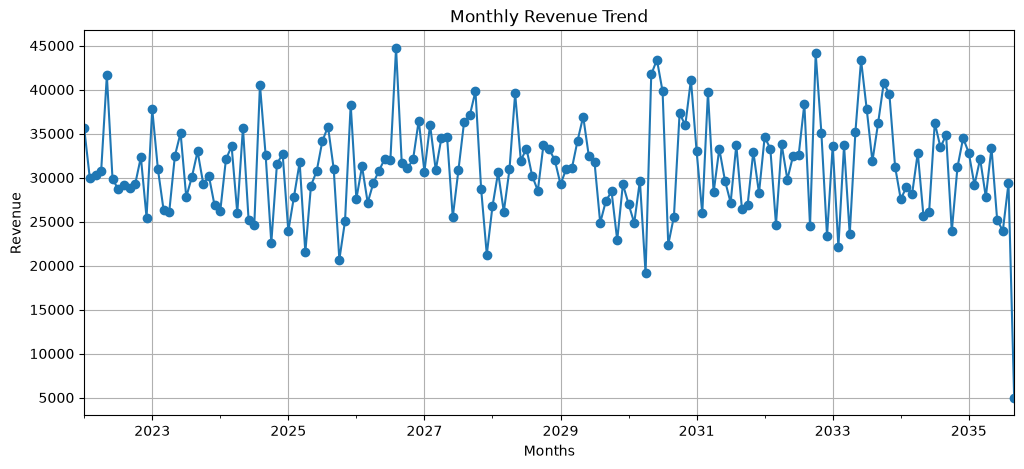

In [41]:
monthly_sales.plot(kind='line', figsize=(12, 5), marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Months')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

In [42]:
quarterly_sales = df.groupby(df['order_date'].dt.to_period('Q'))['revenue'].sum()
quarterly_sales

order_date
2022Q1     95843.06
2022Q2    102258.53
2022Q3     86663.76
2022Q4     87058.95
2023Q1     95118.92
2023Q2     93667.22
2023Q3     90837.49
2023Q4     86292.16
2024Q1     91844.60
2024Q2     86821.70
2024Q3     97701.72
2024Q4     86841.11
2025Q1     83489.60
2025Q2     81328.89
2025Q3    100951.89
2025Q4     84031.95
2026Q1     86007.08
2026Q2     92314.78
2026Q3    108454.80
2026Q4     99593.03
2027Q1     97517.76
2027Q2     94587.36
2027Q3    104247.26
2027Q4     89799.53
2028Q1     83442.79
2028Q2    102429.83
2028Q3     92019.37
2028Q4     98952.81
2029Q1     91246.08
2029Q2    103524.61
2029Q3     83904.74
2029Q4     80563.81
2030Q1     81501.92
2030Q2    104222.95
2030Q3     87767.61
2030Q4    114391.98
2031Q1     98631.28
2031Q2     91257.44
2031Q3     87257.30
2031Q4     88104.81
2032Q1     92560.13
2032Q2     96002.04
2032Q3     95464.81
2032Q4    102557.65
2033Q1     89428.95
2033Q2    102057.00
2033Q3    105778.98
2033Q4    111460.79
2034Q1     84588.97
2034Q2   

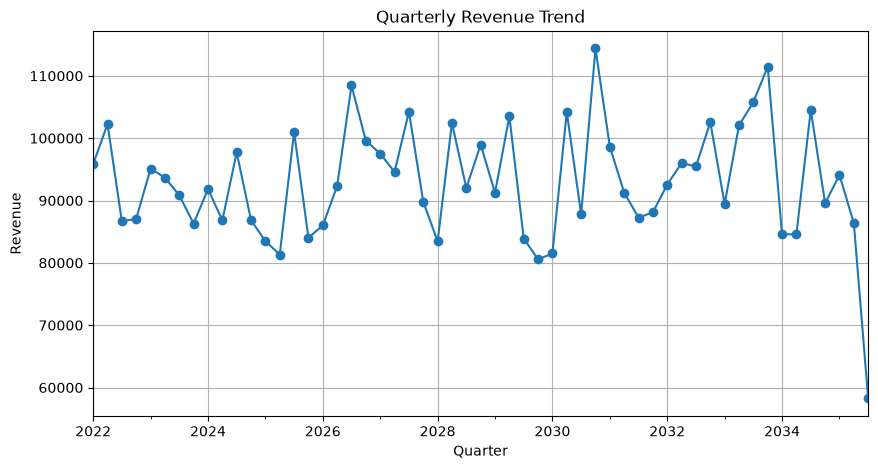

In [43]:
quarterly_sales.plot(kind='line', figsize=(10, 5), marker='o')

plt.title('Quarterly Revenue Trend')
plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

In [44]:
# Quarterly Revenue Trend Observation
# There are variation over time in the quarterly revenue as well. Typically, revenue falls between 80,000 and 115,000. 
# At the end of the time, the lowest quarterly revenue was approximately 58,000, while the highest was approximately 115,000. 
# In general, there is no discernible long-term upward or downward trend in quarterly revenue.

In [45]:
5. #Product analysis: top 10 best-selling products; revenue by product category (bar chart)
df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'product_category',
 'region',
 'quantity',
 'unit_price',
 'discount',
 'payment_method',
 'delivery_days',
 'customer_rating',
 'revenue']

In [46]:
product_sales = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)

In [47]:
product_sales

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

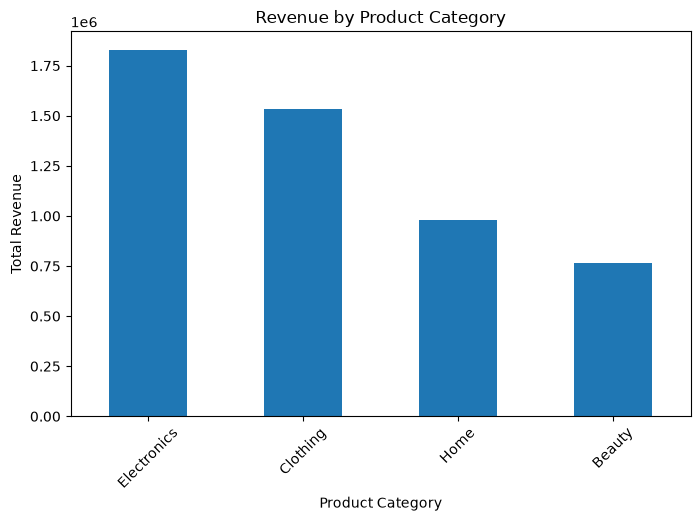

In [48]:
product_sales.plot(kind='bar', figsize=(8,5))

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [49]:
#Observation fro revenue productcategory
# Electronics has the highest revenue, followed by Clothing. Home and Beauty have lower revenue, with Beauty having the lowest revenue. 
# This shows that Electronics is the best-performing product category in terms of revenue.

In [50]:
6.#Heatmap: Correlation matrix for numerical variables
correlation = df.select_dtypes(include='number').corr()
correlation

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
order_id,1.000000,0.017504,-0.003368,0.017876,0.011110,0.006196,0.004984,0.009681
customer_id,0.017504,1.000000,0.023097,0.009748,-0.012617,-0.017440,0.020302,0.025499
quantity,-0.003368,0.023097,1.000000,0.001498,-0.004302,-0.008748,0.019168,0.623564
unit_price,0.017876,0.009748,0.001498,1.000000,0.013215,0.015623,0.005025,0.678032
discount,0.011110,-0.012617,-0.004302,0.013215,1.000000,-0.000382,0.012776,-0.139296
delivery_days,0.006196,-0.017440,-0.008748,0.015623,-0.000382,1.000000,-0.017625,0.005444
customer_rating,0.004984,0.020302,0.019168,0.005025,0.012776,-0.017625,1.000000,0.012446
revenue,0.009681,0.025499,0.623564,0.678032,-0.139296,0.005444,0.012446,1.000000


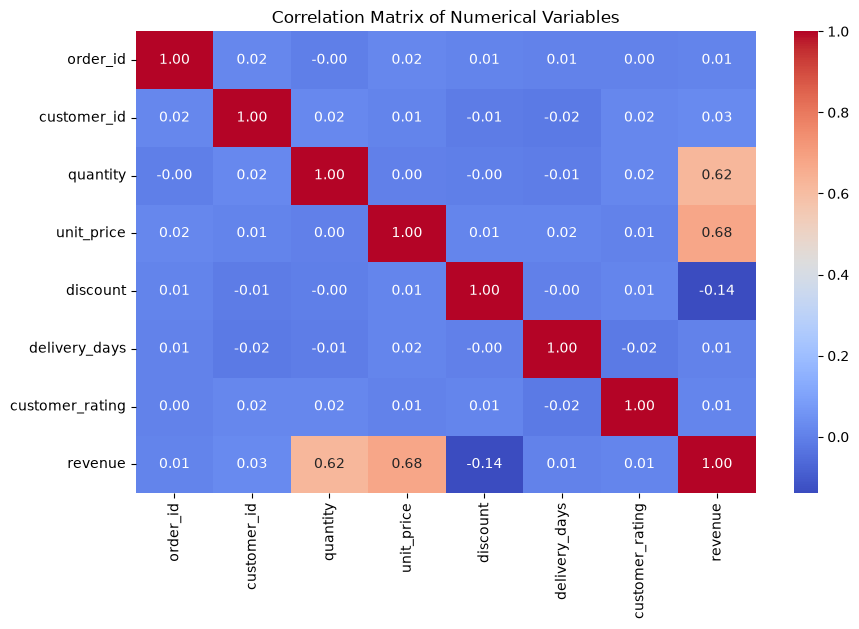

In [51]:
plt.figure(figsize=(10, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

In [52]:
# Observation for correlation matrix between numerical variables.

# Revenue has a strong positive relationship with unit price (0.68) and quantity (0.62). Discount has a weak negative relationship with revenue (-0.14). 
# The other variables have very little relationship with revenue.

In [53]:
df.groupby('region')['revenue'].sum()

region
East     1236044.23
North    1281508.45
South    1246640.90
West     1345582.16
Name: revenue, dtype: float64

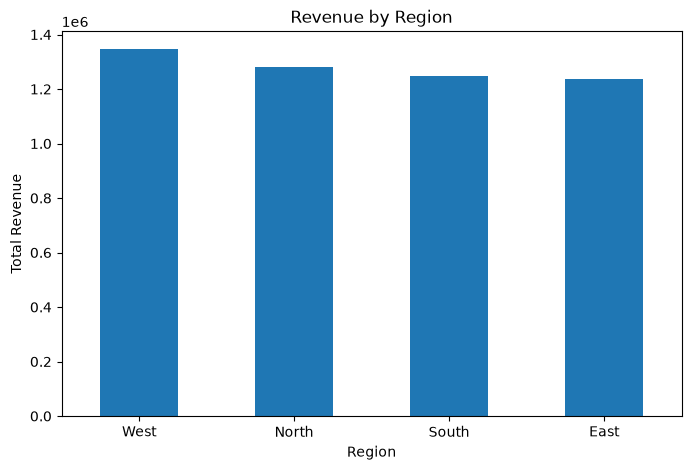

In [54]:
7. #  At least one additional visualisation of your choice that reveals a non-obvious insight

region_sales = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', figsize=(8,5))
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

In [55]:
#observation and visualisation that reveals a non-obvious insight

# The West region has the highest revenue, while the East region has the lowest revenue. 
# However, the difference between the regions is relatively small, showing that revenue is fairly evenly distributed across all regions.

In [56]:
9. # Conclusion

# Customer behaviour, product quality, revenue trends, and correlations between numerical variables were all revealed by the exploratory data analysis.

#  Business Guidelines:

# 1. Pay attention to product categories that are performing well:  Give the product categories with the highest revenue greater inventory and promotional resources. Concurrently, look into the reasons behind the lower sales of underperforming categories.
# 2. Apply consumer demographics for focused advertising:  Create marketing efforts that are specifically targeted at the largest client age group and gender segment found in the analysis. Customer engagement and campaign relevance may both benefit from this.
# 3. Consider revenue trends when planning inventory:  To predict times when demand will be higher, use the quarterly revenue trends. To lower the danger of stock shortages, boost inventory and promotional efforts prior to periods of high performance.
# 4. Maintain focus on revenue-related factors:  Determine which numerical variables have better correlations with revenue by using the correlation analysis. Data-driven business choices can be supported by routinely monitoring these variables.
# 5.Give top-selling items priority:  Keep plenty of the best-performing products on hand, and think about marketing tactics that entice consumers to buy them in addition to other underperforming goods.

9.0